# Working with imaging phenotypes (Y data)

In real neuroimaging studies, you rarely have a single group-average brain map ready to go. More often you have individual subject images that you need to transform into a group-level phenotype before you can run a colocalization.

This notebook covers:
- Computing group-level effect sizes with `transform_y()` (Hedges' g, Cohen's d, z-scores, percentiles)
- Removing confounding effects with `clean_y()` (covariate regression, ComBat harmonization)

We use the `"anorexianervosa"` example dataset: 50 patients and 50 healthy controls with parcellated grey matter values.

> **Note:** This dataset is **simulated** and not intended for scientific use. The numbers are realistic but fabricated — do not draw any clinical or scientific conclusions from it.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

## Load the example dataset

The anorexia nervosa example dataset contains parcellated grey matter maps for 100 subjects. The group labels are encoded in the subject IDs.

In [2]:
from nispace.datasets import fetch_example, fetch_reference

# load individual subject data
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")

# extract group labels from subject IDs
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

print(f"Data: {an_data.shape[0]} subjects x {an_data.shape[1]} parcels")
print(f"Groups: {pd.Series(groups).value_counts().to_dict()}")
an_data.head(3)

INFO | 01/06/26 12:40:31 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200Parcels7Networks.


Data: 100 subjects x 200 parcels
Groups: {'AN': 50, 'HC': 50}


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
sub-001AN,0.607015,0.666528,0.688496,0.334800,0.329322,0.562516,0.451181,0.573052,0.401972,0.672295,...,0.650113,0.603506,0.630403,0.408940,0.371325,0.644625,0.484537,0.658464,0.627889,0.632716
sub-002AN,0.788824,0.554837,0.647586,0.499502,0.445121,0.631092,0.287457,0.448134,0.340598,0.358523,...,0.845582,0.479605,0.362507,0.475748,0.407921,0.661211,0.546743,0.485640,0.694245,0.543393
sub-003AN,0.735806,0.709086,0.696516,0.500039,0.323851,0.514095,0.494061,0.544062,0.418107,0.600964,...,0.792297,0.628415,0.523004,0.585326,0.463725,0.587687,0.596047,0.645918,0.566473,0.550393


## Setting up NiSpace with individual subject data

When `y` is a DataFrame with one row per subject, NiSpace treats it as individual-level data. We pass the group vector separately when we call `transform_y()`.

We also load the PET reference data.

In [3]:
from nispace.api import NiSpace

pet_maps = fetch_reference("pet", parcellation="Schaefer200",
                           collection="UniqueTracers", print_references=False)

nsp = NiSpace(
    x=pet_maps,
    y=an_data,         # individual subject maps — one row per subject
    parcellation="Schaefer200",
    n_proc=4,
    seed=42
)
nsp.fit()
print(f"Fitted. Y shape: {nsp.get_y().shape}")

INFO | 01/06/26 12:40:31 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 12:40:31 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 12:40:31 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:40:31 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


INFO | 01/06/26 12:40:31 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 01/06/26 12:40:31 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 01/06/26 12:40:31 | nispace.api: Got 'y' data for 100 x 200 parcels.


INFO | 01/06/26 12:40:31 | nispace.api: Z-standardizing 'X' data.


INFO | 01/06/26 12:40:31 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


Fitted. Y shape: (100, 200)


## Computing group-level effect sizes with `transform_y()`

To run a spatial colocalization, we need a single group-level map. `transform_y()` computes this for us, using a formula that specifies the comparison.

The group vector tells NiSpace which subjects belong to which group. The convention is that group "a" (here: `AN`) is compared against group "b" (here: `HC`).

### Hedges' g

Hedges' g is a bias-corrected version of Cohen's d — the most common effect size metric for group comparisons. A negative g at a given parcel means the AN group has lower grey matter there compared to controls.

In [4]:
# compute Hedges' g: AN vs. HC
# the formula "hedges(a,b)" computes Hedges' g for group a (AN) vs. group b (HC)
nsp.transform_y(
    transform="hedges(a,b)",
    groups=groups  # vector of group labels, same length as number of subjects
)

hedges_g = nsp.get_y()
print(f"After transform_y: {hedges_g.shape}  (one row = one group comparison)")
print(f"Value range: [{hedges_g.values.min():.2f}, {hedges_g.values.max():.2f}]")
hedges_g

INFO | 01/06/26 12:40:31 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 01/06/26 12:40:31 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 01/06/26 12:40:31 | nispace.api: Applying Y transform 'hedges(a,b)'.


INFO | 01/06/26 12:40:31 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


After transform_y: (1, 200)  (one row = one group comparison)
Value range: [-0.24, 0.86]


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
hedges,0.234659,0.056813,0.107451,0.05087,0.536093,0.22262,0.138825,0.136664,0.175492,0.046341,...,0.10195,-0.240146,-0.14014,-0.03309,-0.058849,-0.164091,0.003687,0.119205,0.403226,0.416562


INFO | 01/06/26 12:40:31 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 01/06/26 12:40:31 | nispace.api: Plotting Y data (Y_transform='hedges(a,b)').


INFO | 01/06/26 12:40:31 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


WARNING | 01/06/26 12:40:31 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 01/06/26 12:40:31 | nispace.plotting: brainplot: threshold='auto' → 0.0009347720188088715


INFO | 01/06/26 12:40:31 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 01/06/26 12:40:32 | nispace.core.parcellation: Parcellation 'Schaefer200Parcels7Networks': active space set to 'MNI152NLin2009cAsym'.


INFO | 01/06/26 12:40:32 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


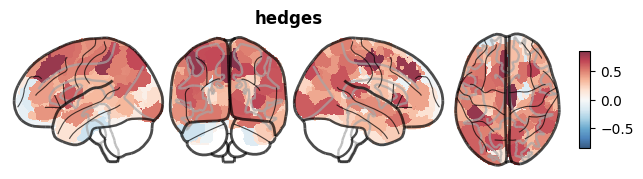

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [5]:
# visualize on the brain
nsp.plot_brain(data="Y", symmetric_cmap=True)

Widespread negative values are expected: anorexia nervosa is associated with global grey matter reductions, most pronounced in frontal and temporal regions.

### Cohen's d

Cohen's d is the non-bias-corrected version. With n=50 per group the difference from Hedges' g is minimal, but it's good to know both are available.

In [6]:
nsp.transform_y(transform="cohen(a,b)", groups=groups)
cohens_d = nsp.get_y()
print(f"Cohen's d range: [{cohens_d.values.min():.2f}, {cohens_d.values.max():.2f}]")

INFO | 01/06/26 12:40:35 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 01/06/26 12:40:35 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 01/06/26 12:40:35 | nispace.api: Applying Y transform 'cohen(a,b)'.


INFO | 01/06/26 12:40:35 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| cohen(a,b)  | 


Cohen's d range: [-0.24, 0.87]


### Z-scores (individual deviation maps)

Instead of a single group map, we can compute a deviation map for each patient: how many standard deviations does this individual deviate from the control mean at each parcel? This is useful for individual-level analyses — see [Notebook 11](intro11_advanced.ipynb).

In [7]:
# z-score: each AN subject mapped relative to HC mean and SD
nsp.transform_y(transform="zscore(a,b)", groups=groups)

zscores = nsp.get_y()
print(f"Z-score maps: {zscores.shape}  (one row per AN subject)")
zscores.head(3)

INFO | 01/06/26 12:40:35 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 01/06/26 12:40:35 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 01/06/26 12:40:35 | nispace.api: Applying Y transform 'zscore(a,b)'.


INFO | 01/06/26 12:40:35 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| zscore(a,b) | 


Z-score maps: (50, 200)  (one row per AN subject)


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
sub-001AN,-0.917006,1.000070,1.132374,-1.605360,-0.771186,0.379098,-0.077323,0.378764,-0.604761,1.196448,...,-0.254770,-0.552606,1.362208,-0.933297,-0.946297,0.840285,-0.186260,0.167540,0.128992,0.551934
sub-002AN,1.005458,-0.029039,0.710286,0.111984,0.356170,1.074949,-1.508936,-0.839125,-1.304369,-2.243848,...,1.885931,-1.872780,-1.198049,-0.258558,-0.572263,1.023198,0.488698,-1.701267,0.837380,-0.358096
sub-003AN,0.444845,1.392190,1.215116,0.117580,-0.824451,-0.112243,0.297631,0.096133,-0.420842,0.414352,...,1.302371,-0.287197,0.335808,0.848146,-0.001928,0.212359,1.023656,0.031869,-0.526657,-0.286777


For colocalization analyses, we typically average across subjects to get one group-level map. The Hedges' g approach does this in one step. But for individual-level colocalization you'd keep all rows and analyze them separately.

## Removing confounds with `clean_y()`

Grey matter maps are affected by confounds that have nothing to do with the disorder: age, sex, total intracranial volume, and scanner site are the usual suspects. `clean_y()` lets you regress these out before running colocalization.

NiSpace distinguishes between two types of regression:

- **"within"**: regression *across parcels* within each map (e.g., regressing out a whole-brain grey matter map to control for global effects)
- **"between"**: regression *across subjects* (e.g., removing age or sex effects)

Let's generate a synthetic age vector for demonstration and show how to regress it out.

In [8]:
# reset to individual subject data for this demo
nsp_clean = NiSpace(
    x=pet_maps,
    y=an_data,
    parcellation="Schaefer200",
    seed=42
)
nsp_clean.fit()

# generate a synthetic age vector: AN mean=25, HC mean=30, SD=5 for both
# (realistic for this kind of study)
rng = np.random.default_rng(42)
age_AN = rng.normal(25, 5, 50)
age_HC = rng.normal(30, 5, 50)
age = np.concatenate([age_AN, age_HC])

# sex: roughly balanced (0=male, 1=female), NiSpace treats string covariates automatically as categorical
sex = rng.permutation(["f"]*80 + ["m"]*20)

print(f"Age: mean={age.mean():.1f}, SD={age.std():.1f}")
print(f"Sex: {(sex=='f').sum()} female, {(sex=='m').sum()} male")

INFO | 01/06/26 12:40:35 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 01/06/26 12:40:35 | nispace.core.parcellation: Building multi-space Parcellation for 'Schaefer200Parcels7Networks' from library.


INFO | 01/06/26 12:40:35 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR


INFO | 01/06/26 12:40:35 | nispace.core.parcellation: Parcellation 'Schaefer200Parcels7Networks': validation passed.


INFO | 01/06/26 12:40:35 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 01/06/26 12:40:35 | nispace.api: Checking input data for 'y' (should be, e.g., subject data):


INFO | 01/06/26 12:40:35 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 01/06/26 12:40:35 | nispace.api: Got 'y' data for 100 x 200 parcels.


INFO | 01/06/26 12:40:35 | nispace.api: Z-standardizing 'X' data.


Age: mean=27.2, SD=4.2
Sex: 80 female, 20 male


In [9]:
# regress age and sex out from the individual subject maps
# how="between" means: regression across subjects
# covariates_between is a DataFrame with one row per subject
covariates = pd.DataFrame({"age": age, "sex": sex}, index=an_data.index)

nsp_clean.clean_y(
    how="between",
    covariates_between=covariates
)

print("Covariate regression done.")
print(f"Y shape after cleaning: {nsp_clean.get_y().shape}")

INFO | 01/06/26 12:40:35 | nispace.api: *** NiSpace.clean_y() - Y covariate regression. ***


INFO | 01/06/26 12:40:35 | nispace.api: Performing covariate regression between maps/subjects (e.g., age, sex, site).


INFO | 01/06/26 12:40:35 | nispace.core.clean_y: Detected categorical covariates: ['sex']; continuous: ['age'].


INFO | 01/06/26 12:40:35 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y.


Regressing 2 between covariate(s) from Y (1 proc):   0%|                                                                       | 0/200 [00:00<?, ?it/s]

Regressing 2 between covariate(s) from Y (1 proc):   0%|▎                                                              | 1/200 [00:01<06:27,  1.95s/it]

Regressing 2 between covariate(s) from Y (1 proc): 100%|████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 102.62it/s]

Covariate regression done.
INFO | 01/06/26 12:40:37 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


Y shape after cleaning: (100, 200)


After cleaning, we can compute effect sizes on the covariate-corrected maps:

In [10]:
nsp_clean.transform_y(transform="hedges(a,b)", groups=groups)
hedges_g_clean = nsp_clean.get_y()

print(f"Hedges' g after covariate regression: range [{hedges_g_clean.values.min():.2f}, {hedges_g_clean.values.max():.2f}]")

INFO | 01/06/26 12:40:37 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 01/06/26 12:40:37 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 01/06/26 12:40:37 | nispace.api: Applying Y transform 'hedges(a,b)'.


INFO | 01/06/26 12:40:37 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


Hedges' g after covariate regression: range [-0.34, 0.69]


### ComBat harmonization

If your data comes from multiple scanners or study sites, `clean_y()` also supports ComBat harmonization (a Bayesian framework for removing scanner effects while preserving biological variability). Pass `combat=True` and include a `"site"` column in your covariates DataFrame:

```python
covariates_with_site = pd.DataFrame({
    "age": age,
    "sex": sex,
    "site": site_labels  # scanner/site identifier per subject
}, index=an_data.index)

nsp_clean.clean_y(
    how="between",
    covariates_between=covariates_with_site,
    combat=True
)
```

ComBat removes site effects while keeping the biological covariates (age, sex) protected.

## The full preprocessing pipeline

Putting it all together, a typical preprocessing pipeline before colocalization looks like this:

```python
nsp = NiSpace(x=pet_maps, y=an_data, parcellation="Schaefer200")
nsp.fit()                                      # parcellate
nsp.clean_y(                                   # remove confounds
    how="between",
    covariates_between=covariates
)
nsp.transform_y(                               # compute effect sizes
    transform="hedges(a,b)",
    groups=groups
)
nsp.colocalize("spearman")                     # correlate with reference
nsp.permute("groups", n_perm=10000)            # permutation test (group labels)
nsp.plot()
```

Note that when group labels are permuted (`permute("groups")`), we permute the subject labels before computing the effect size — this gives a more principled null model than permuting the maps. This is covered in detail in [Notebook 5](intro05_null_models.ipynb).

## Summary

| Method | What it does |
|--------|--------------|
| `transform_y("hedges(a,b)", groups=...)` | Hedges' g per parcel (group a vs. b) |
| `transform_y("cohen(a,b)", groups=...)` | Cohen's d per parcel |
| `transform_y("zscore(a,b)", groups=...)` | Z-score per subject (group a relative to b) |
| `clean_y(how="between", covariates_between=df)` | Regress out between-subject confounds |
| `clean_y(how="within", covariates_within=df)` | Regress out within-map confounds (e.g., grey matter) |
| `clean_y(..., combat=True)` | ComBat site harmonization |

Next: [Notebook 5](intro05_null_models.ipynb) covers the null model methods in detail.